# **I. Descriptive Statistics**

## 1. **The Purpose of Descriptive Statistics**
* **Definition:** Analysis that helps describe the basic features of a dataset and obtains a short summary about the sample and measures of the data.
* **Purpose:** It is an essential first step to explore and understand your data before spending time building complicated predictive models.

## 2. **Summarizing Data in Pandas**
* **Numerical Variables (`describe`):** 
  * Applying `df.describe()` automatically computes basic statistics for all numerical columns.
  * It shows the count, mean, standard deviation, quartiles (25th, 50th, 75th percentiles), and extreme values (min/max).
  * NaN (missing) values are automatically skipped.
* **Categorical Variables (`value_counts`):**
  * Categorical variables contain discrete values divided into groups (e.g., `front-wheel drive`, `rear-wheel drive`).
  * Using `df['column'].value_counts()` summarizes this data by counting the number of occurrences for each category.

## 3. **Visualizing Data Distributions and Relationships**
* **Box Plots (Comparing Groups):**
  * Great for visualizing the distribution of numeric data and comparing different categories (e.g., price distribution across different drive-wheel types).
  * **Features shown:** Median (middle point), Upper Quartile (75th percentile), Lower Quartile (25th percentile), Inter-quartile range (IQR, the data between quartiles), Extremes (1.5 * IQR), and Outliers (individual dots outside extremes).
* **Scatter Plots (Continuous Variables):**
  * Used to understand the relationship between two continuous variables (e.g., predicting `price` based on `engine-size`).
  * **Axes setup:** The predictor variable (used to predict the outcome) goes on the x-axis, while the target variable (the outcome you are trying to predict) goes on the y-axis.
  * Always label axes and add a title to make the plot understandable.

In [3]:
# installing matplotlib
import matplotlib
print(matplotlib.__version__)

3.11.2


==== DỮ LIỆU BAN ĐẦU ====
   price  engine_size drive_wheels
0  13495          130          fwd
1  16500          152          rwd
2  18920          109          fwd
3  12000          136          fwd
4  32250          209          rwd
5  35050          209          4wd
6  15000          120          fwd
7  12500          110          fwd
8   8900           90          4wd


==== BƯỚC 1: THỐNG KÊ MÔ TẢ BIẾN SỐ (describe) ====
              price  engine_size
count      9.000000     9.000000
mean   18290.555556   140.555556
std     9181.888574    42.632473
min     8900.000000    90.000000
25%    12500.000000   110.000000
50%    15000.000000   130.000000
75%    18920.000000   152.000000
max    35050.000000   209.000000


==== BƯỚC 2: TỔNG HỢP BIẾN PHÂN LOẠI (value_counts) ====
drive_wheels
fwd    5
rwd    2
4wd    2
Name: count, dtype: int64




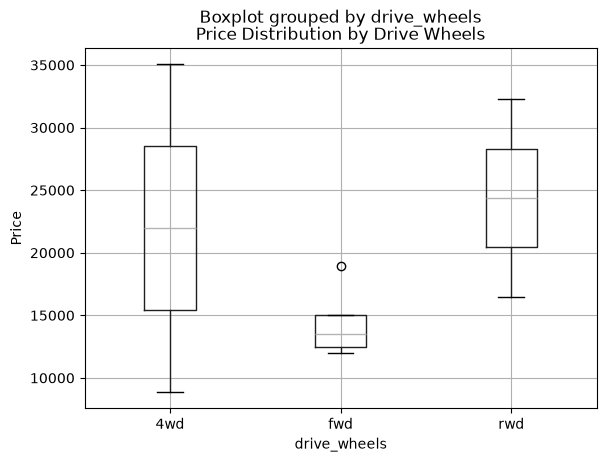

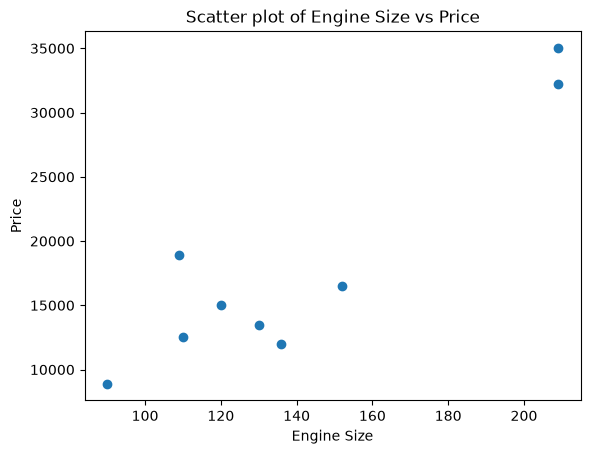

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Tạo DataFrame mẫu giả lập dữ liệu xe hơi
df = pd.DataFrame({
    'price': [13495, 16500, 18920, 12000, 32250, 35050, 15000, 12500, 8900],
    'engine_size': [130, 152, 109, 136, 209, 209, 120, 110, 90],
    'drive_wheels': ['fwd', 'rwd', 'fwd', 'fwd', 'rwd', '4wd', 'fwd', 'fwd', '4wd']
})

print("==== DỮ LIỆU BAN ĐẦU ====")
print(df)
print("\n")

# Bước 1: Xem thống kê mô tả cho các biến số (numeric variables)
print("==== BƯỚC 1: THỐNG KÊ MÔ TẢ BIẾN SỐ (describe) ====")
print(df.describe())
print("\n")

# Bước 2: Đếm tần suất cho các biến phân loại (categorical variables)
print("==== BƯỚC 2: TỔNG HỢP BIẾN PHÂN LOẠI (value_counts) ====")
print(df['drive_wheels'].value_counts())
print("\n")

# Bước 3: Trực quan hóa dữ liệu (Các lệnh này sẽ hiển thị biểu đồ trên máy của bạn)
# Vẽ Box Plot để so sánh giá theo từng loại dẫn động (drive_wheels)
df.boxplot(column='price', by='drive_wheels')
plt.title('Price Distribution by Drive Wheels')
plt.ylabel('Price')

# Vẽ Scatter Plot để xem mối liên hệ giữa kích thước động cơ và giá xe
plt.figure()
plt.scatter(x=df['engine_size'], y=df['price'])
plt.title('Scatter plot of Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')

plt.show()

---
# **II. GroupBy:Data Grouping and Pivot Tables**

## 1. **The Concept of Grouping Data (`groupby`)**
* **Definition:** A method used on categorical variables to group data into subsets according to different categories.
* **Purpose:** Helps discover relationships between categorical variables and a target variable (e.g., how different `drive-wheels` types affect `price`).
* **Flexibility:** You can group by a single variable or multiple variables simultaneously.
* **Aggregation:** After grouping, you typically apply an aggregate function like `mean()` to summarize the target variable for each group.

## 2. **Transforming Data with Pivot Tables**
* **The Issue:** Grouped data with multiple variables can be difficult to read and visualize in a standard list format.
* **Definition:** A table where one variable is displayed along the columns and another variable is displayed along the rows, turning the data into a rectangular grid.
* **Purpose:** Makes data significantly easier to understand and visualize, similar to pivot tables in Excel.

## 3. **Visualizing with Heat Maps**
* **Definition:** A plot that takes a rectangular grid of data (like a pivot table) and assigns a color intensity based on the data value at each grid point.
* **Purpose:** Provides quick visual clues about the relationship between multiple variables and a target variable (e.g., higher prices showing up as distinct colors).

## 4. **Implementation in Python**
* **Grouping Data:** `df[['col1', 'col2', 'target']].groupby(['col1', 'col2']).mean()`
* **Pivot Tables:** `df.pivot(index='row_variable', columns='column_variable', values='target_variable')`
* **Heat Maps:** Uses Matplotlib's `pyplot.pcolor()` over the pivot table, commonly applying a color map (like a red-blue scheme) to differentiate values.

     DỮ LIỆU BAN ĐẦU     
  drive_wheels   body_style  price
0          rwd  convertible  35000
1          rwd      hardtop  32000
2          fwd    hatchback   8000
3          fwd        sedan  12000
4          4wd    hatchback   7500
5          4wd        sedan  10000
6          rwd        sedan  18000
7          fwd    hatchback   9500


     1. DỮ LIỆU SAU KHI GỘP (groupby.mean)     
  drive_wheels   body_style    price
0          4wd    hatchback   7500.0
1          4wd        sedan  10000.0
2          fwd    hatchback   8750.0
3          fwd        sedan  12000.0
4          rwd  convertible  35000.0
5          rwd      hardtop  32000.0
6          rwd        sedan  18000.0


     2. BẢNG PIVOT TABLE     
body_style    convertible  hardtop  hatchback    sedan
drive_wheels                                          
4wd                   0.0      0.0     7500.0  10000.0
fwd                   0.0      0.0     8750.0  12000.0
rwd               35000.0  32000.0        0.0  18000.0




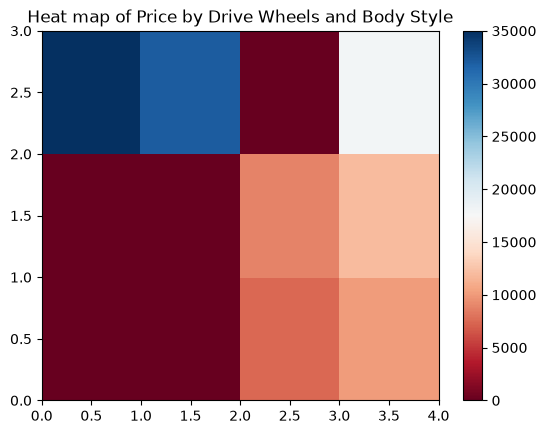

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tạo DataFrame mẫu giả lập dữ liệu xe hơi
df = pd.DataFrame({
    'drive_wheels': ['rwd', 'rwd', 'fwd', 'fwd', '4wd', '4wd', 'rwd', 'fwd'],
    'body_style': ['convertible', 'hardtop', 'hatchback', 'sedan', 'hatchback', 'sedan', 'sedan', 'hatchback'],
    'price': [35000, 32000, 8000, 12000, 7500, 10000, 18000, 9500]
})

print("     DỮ LIỆU BAN ĐẦU     ")
print(df)
print("\n")

# Bước 1: Trích xuất 3 cột, gộp nhóm theo loại dẫn động và kiểu dáng, tính giá trung bình
# as_index=False giúp giữ lại cấu trúc DataFrame thông thường thay vì MultiIndex
df_group = df[['drive_wheels', 'body_style', 'price']]
grouped_test = df_group.groupby(['drive_wheels', 'body_style'], as_index=False).mean()

print("     1. DỮ LIỆU SAU KHI GỘP (groupby.mean)     ")
print(grouped_test)
print("\n")

# Bước 2: Chuyển đổi thành Pivot Table để dễ quan sát (hệ thống dạng lưới)
grouped_pivot = grouped_test.pivot(index='drive_wheels', columns='body_style', values='price')

# Điền 0 vào các ô không có dữ liệu (NaN) để bảng nhìn sạch sẽ hơn
grouped_pivot = grouped_pivot.fillna(0)

print("     2. BẢNG PIVOT TABLE     ")
print(grouped_pivot)
print("\n")

# Bước 3: Trực quan hóa dữ liệu bằng Heat Map (Các lệnh này sẽ vẽ biểu đồ)
plt.pcolor(grouped_pivot, cmap='RdBu') # Sử dụng hệ màu Đỏ-Xanh theo ví dụ
plt.colorbar() # Hiển thị thanh đo màu
plt.title('Heat map of Price by Drive Wheels and Body Style')
plt.show()

---
# **III. Correlation Between Variables**

## 1. **The Concept of Correlation**
* **Definition:** A statistical metric for measuring to what extent different variables are interdependent (i.e., if one variable changes, how does it affect the other?).
* **Crucial Rule:** Correlation does not imply causation. For example, rain and umbrellas are highly correlated, but we cannot say umbrellas cause rain.
* **General Focus:** In data science, predicting outcomes often relies heavily on correlation rather than proving strict causation.

## 2. **Types of Correlation (Linear Relationships)**
1. **Positive Correlation:** As one variable increases, the other variable also increases. 
   * *Example:* `engine-size` vs. `price`. The regression line is steep with a positive slope.
2. **Negative Correlation:** As one variable increases, the other variable decreases.
   * *Example:* `highway-mpg` vs. `price`. The regression line is steep with a negative slope. Despite being negative, it is still a strong predictor.
3. **Weak Correlation:** Changes in one variable do not reliably follow a trend in relation to the other.
   * *Example:* `peak-rpm` vs. `price`. Both low and high RPMs map to varying prices. The regression line is flat, meaning it cannot be used as a reliable predictor.

## 3. **Visualizing Correlation in Python**
* **Scatter Plots with Regression Lines:** Plotting data points along with a fitted straight line helps visualize the steepness and direction of the relationship.
* **`seaborn.regplot`:** A method from the Seaborn library specifically used to plot data and a linear regression model fit.

==== DỮ LIỆU BAN ĐẦU ====
   engine_size  highway_mpg  peak_rpm  price
0           90           45      5000   8000
1          110           40      5500  10000
2          130           35      5200  14000
3          150           30      6000  18000
4          170           25      4800  22000
5          200           20      5400  30000
6          250           15      5000  40000




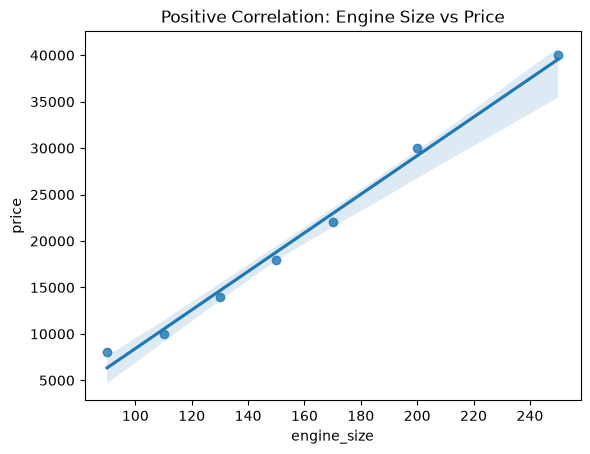

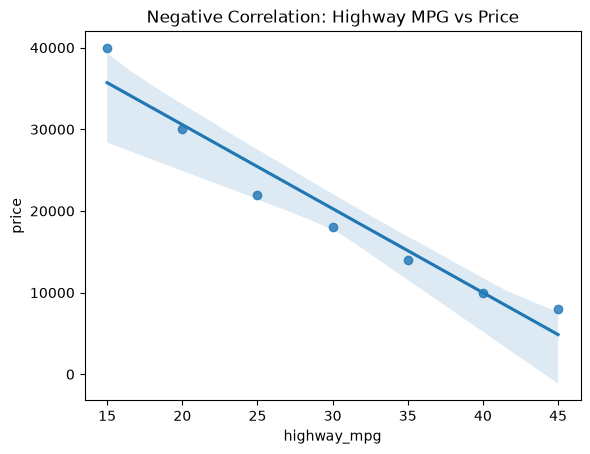

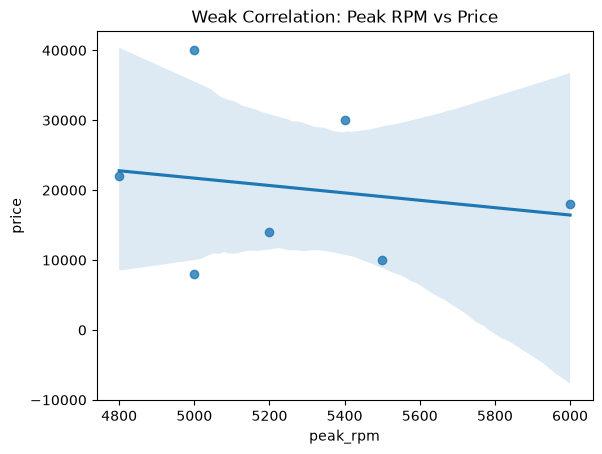

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tạo DataFrame mẫu mô phỏng 3 mối tương quan so với Giá (price)
df = pd.DataFrame({
    'engine_size': [90, 110, 130, 150, 170, 200, 250],  # Tăng dần cùng price (Positive)
    'highway_mpg': [45, 40, 35, 30, 25, 20, 15],        # Giảm dần khi price tăng (Negative)
    'peak_rpm': [5000, 5500, 5200, 6000, 4800, 5400, 5000], # Biến động ngẫu nhiên (Weak)
    'price': [8000, 10000, 14000, 18000, 22000, 30000, 40000]
})

print("==== DỮ LIỆU BAN ĐẦU ====")
print(df)
print("\n")

# ==== CÁC LỆNH VẼ BIỂU ĐỒ (VISUALIZATIONS) ====

# 1. Tương quan dương (Positive Correlation): Đường hồi quy dốc lên
plt.figure()
sns.regplot(x='engine_size', y='price', data=df)
plt.title('Positive Correlation: Engine Size vs Price')

# 2. Tương quan âm (Negative Correlation): Đường hồi quy dốc xuống
plt.figure()
sns.regplot(x='highway_mpg', y='price', data=df)
plt.title('Negative Correlation: Highway MPG vs Price')

# 3. Tương quan yếu (Weak Correlation): Đường hồi quy nằm ngang/phẳng
plt.figure()
sns.regplot(x='peak_rpm', y='price', data=df)
plt.title('Weak Correlation: Peak RPM vs Price')

plt.show()